In [1]:
import lsdb
import matplotlib.pyplot as plt
import numpy as np

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
for f in "grizuy":
    path = f"outputs/{f}_dia_object"
    dia_obj = lsdb.open_catalog(path)
    dia_obj_pruned = dia_obj.prune_empty_partitions()
    moc = dia_obj_pruned.hc_structure.moc
    moc.write(f"mocs/dia_obj_{f}.fits", overwrite=True)
    fig, ax = dia_obj_pruned.plot_pixels(plot_title=f"DIA Object Coverage — {f} band")
    fig.savefig(f"plots/sky_coverage_{f}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/lsdb/catalog/dataset/healpix_dataset.py:1281: RuntimeWarning: Pruning empty partitions is expensive. It may run slow!
  warnings.warn("Pruning empty partitions is expensive. It may run slow!", RuntimeWarning)
Computing Catalog: 100%|██████████| 16540/16540 [00:45<00:00, 367.05it/s]
/local/tmp/ipykernel_2775582/783064149.py:6: DeprecationWarning: This method is deprecated. Use MOC.save(path, "fits") instead!
  moc.write(f"mocs/dia_obj_{f}.fits", overwrite=True)
/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/lsdb/catalog/dataset/healpix_dataset.py:1281: RuntimeWarning: Pruning empty partitions is expensive. It may run slow!
  warnings.warn("Pruning empty partitions is expensive. It may run slow!", RuntimeWarning)
Computing Catalog: 100%|██████████| 16622/16622 [00:42<00:00, 391.22it/s]
/local/tmp/ipykernel_2775582/783064149.py:6: DeprecationWarning: This method is deprecated. Use MOC.save(path, "fits")

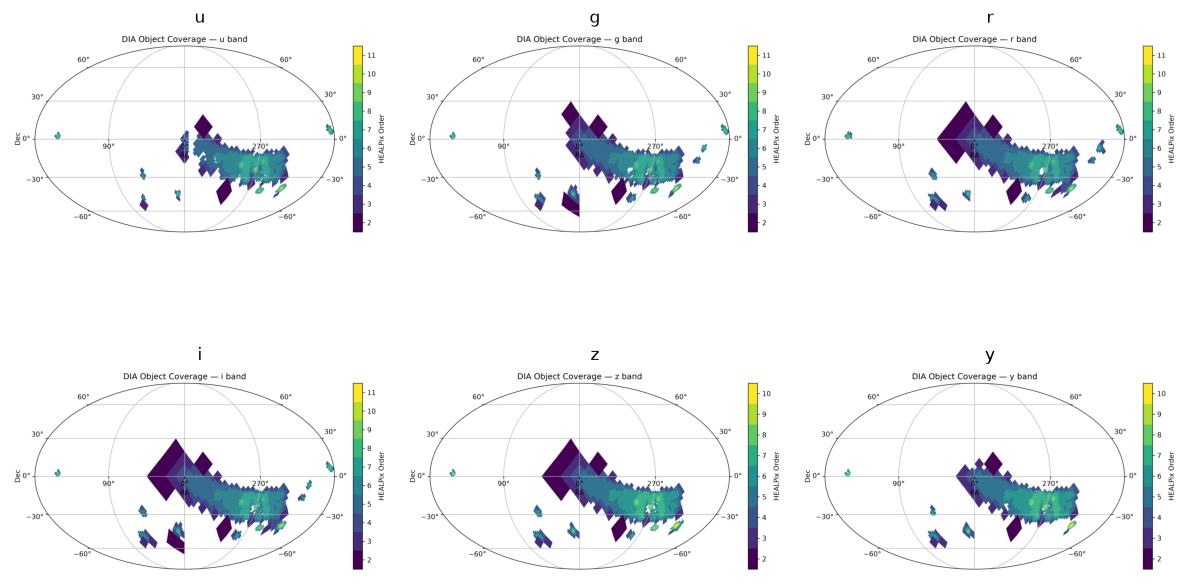

In [4]:
import matplotlib.image as mpimg

filters = ["u", "g", "r", "i", "z", "y"]
files = [f"plots/sky_coverage_{f}.png" for f in filters]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, f, filt in zip(axes, files, filters):
    img = mpimg.imread(f)
    ax.imshow(img)
    ax.set_title(filt)
    ax.axis("off")

fig.tight_layout()
fig.savefig("plots/sky_coverage_combined.png", dpi=300, bbox_inches="tight")